# Dev/08 Envelope Layer Tests

This notebook validates the read-only beam-envelope layer using real MAD-X TWISS output through `cpymad`. It demonstrates the GUI-facing workflow: choose a machine state, choose beam-size assumptions, run MAD-X, then display nominal and harmonic-modified envelopes.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cycle_time import RCSRamp
from machine_state import MachineState
from tune_matching import normalise_harmonic_inputs
from errors import write_error_table
from orbit_branch import (
    OrbitBranch,
    OrbitBranchConfig,
    compare_orbit_results,
    summarise_orbit_difference,
)
from envelope import (
    EnvelopeInputs,
    evaluate_envelope_from_machine_state,
    evaluate_envelope_from_twiss,
    compare_envelopes,
    geometric_emittances_m_rad,
    pi_mm_mrad_to_m_rad,
    plot_envelope,
    plot_sigma,
    plot_envelope_comparison,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)

## Build nominal and large-harmonic machine states

The defaults here match the intended GUI starting point: 300 pi mm mrad RMS emittance in both planes, 3 sigma display, and 0.2% momentum spread. The large-harmonic case uses the same real MAD-X path as the tune layer; it is deliberately exaggerated so the envelope change is visible.

In [2]:
LATTICE_FOLDER = "../Lattice_Files/00_Simplified_Lattice"
OUTPUT_DIR = Path("envelope_tests")
CYCLE_TIME_MS = 2.5

beam_state = RCSRamp().state_at(CYCLE_TIME_MS)

nominal_state = MachineState.from_defaults(
    beam_state=beam_state,
    metadata={"case": "nominal_envelope"},
)

large_harmonics = normalise_harmonic_inputs(
    {
        "D7SIN": 20.0,
        #"D8SIN": -10.0,
        "F8SIN": 20.0,
        #"F9COS": 8.0,
    }
)
large_harmonic_state = MachineState.from_defaults(
    beam_state=beam_state,
    harmonic_tunes=large_harmonics,
    metadata={"case": "large_harmonic_envelope"},
)

inputs_nominal = EnvelopeInputs(label="nominal")
inputs_harmonic = EnvelopeInputs(label="large harmonics")

beam_state.summary_dict(), dict(large_harmonics)

({'cycle_time_ms': 2.5,
  'kinetic_energy_MeV': 139.03252304304772,
  'kinetic_energy_GeV': 0.13903252304304772,
  'total_energy_MeV': 1077.3046112030477,
  'total_energy_GeV': 1.0773046112030478,
  'gamma': 1.1481793232448145,
  'beta': 0.4913821178913615,
  'momentum_MeV_c': 529.3682214670833,
  'momentum_GeV_c': 0.5293682214670834,
  'brho_Tm': 1.7657823182032266,
  'normalised_momentum': 1.434091013579428},
 {'D7SIN': 20.0,
  'D7COS': 0.0,
  'D8SIN': 0.0,
  'D8COS': 0.0,
  'F8SIN': 20.0,
  'F8COS': 0.0,
  'F9SIN': 0.0,
  'F9COS': 0.0})

## Run MAD-X and calculate envelopes

Both cases run through `MadxModel` via the envelope workflow wrapper. The envelope layer then consumes the resulting TWISS tables; it does not create synthetic optics data.

In [3]:
nominal = evaluate_envelope_from_machine_state(
    nominal_state,
    lattice_folder=LATTICE_FOLDER,
    output_dir=str(OUTPUT_DIR / "nominal_madx"),
    inputs=inputs_nominal,
)

harmonic = evaluate_envelope_from_machine_state(
    large_harmonic_state,
    lattice_folder=LATTICE_FOLDER,
    output_dir=str(OUTPUT_DIR / "large_harmonic_madx"),
    inputs=inputs_harmonic,
)

nominal.envelope_df[["name", "s", "betx", "bety", "x", "y", "dx", "dy"]].head()

,name,s,betx,bety,x,y,dx,dy
#s,synchrotron$start:1,0.00,10.440300,5.965648,0.0,0.0,2.452101,0.0
sp0_datum,sp0_datum:1,0.00,10.440300,5.965648,0.0,0.0,2.452101,0.0
sp0_dipfr8,sp0_dipfr8:1,0.16,10.214678,6.336057,0.0,0.0,2.509019,0.0
sp0_dipfr9,sp0_dipfr9:1,0.36,9.939212,6.828548,0.0,0.0,2.581349,0.0
sp0_dipfr10,sp0_dipfr10:1,0.39,9.898958,6.905020,0.0,0.0,2.592243,0.0


## Summary tables for the GUI

The summary table is intentionally compact: it gives the GUI a per-plane maximum sigma and the largest plus/minus envelope excursions.

In [4]:
comparison = compare_envelopes([nominal, harmonic])
comparison

,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,nominal,x,3.0,0.002,geometric,0.0003,0.0003,75.585265,sp8_qf:1,135.788356,226.755795,sp8_qf:1,135.788356,-226.755795,sp8_qf:1,135.788356
1,nominal,y,3.0,0.002,geometric,0.0003,0.0003,70.830435,sp8_qdfr4:1,133.840656,212.491305,sp8_qdfr4:1,133.840656,-212.491305,sp8_qdfr4:1,133.840656
2,large harmonics,x,3.0,0.002,geometric,0.0003,0.0003,82.478700,sp1_qf:1,21.434382,247.436101,sp1_qf:1,21.434382,-247.436101,sp1_qf:1,21.434382
3,large harmonics,y,3.0,0.002,geometric,0.0003,0.0003,78.810488,sp6_qdfr4:1,101.168092,236.431464,sp6_qdfr4:1,101.168092,-236.431464,sp6_qdfr4:1,101.168092


## Nominal horizontal and vertical envelopes

These are the basic plots expected in the GUI: orbit plus/minus the selected n-sigma beam envelope.

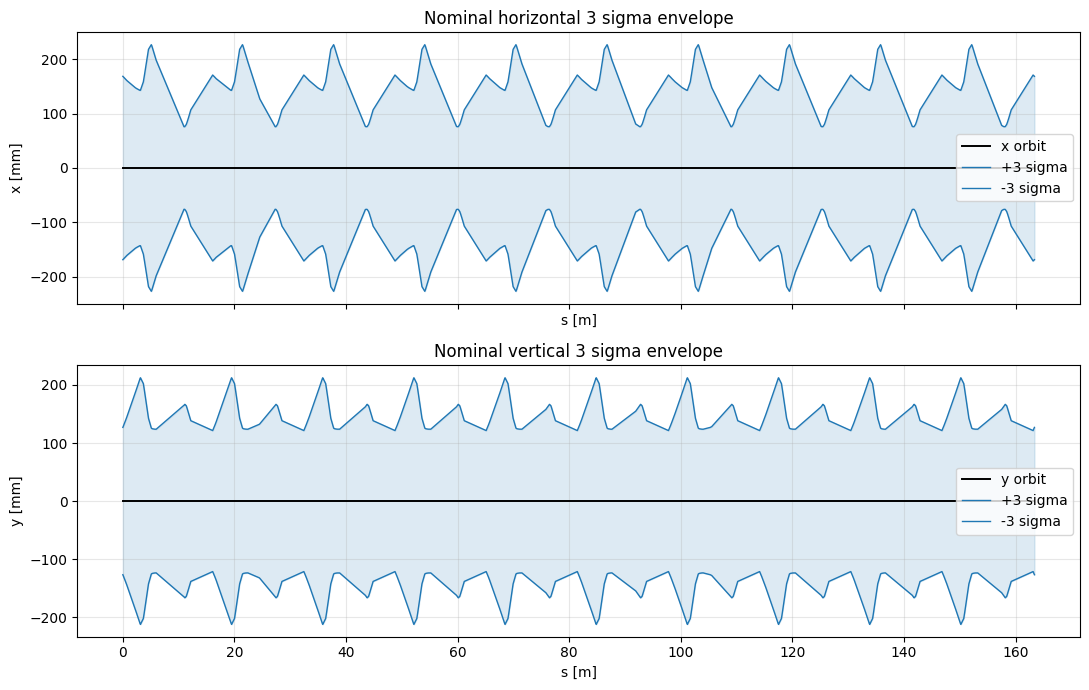

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_envelope(nominal, plane="x", ax=axes[0], title="Nominal horizontal 3 sigma envelope")
plot_envelope(nominal, plane="y", ax=axes[1], title="Nominal vertical 3 sigma envelope")
plt.tight_layout()

## Beam size from beta and dispersion

This view helps distinguish envelope changes caused by beta beating from those caused by dispersion and momentum spread.

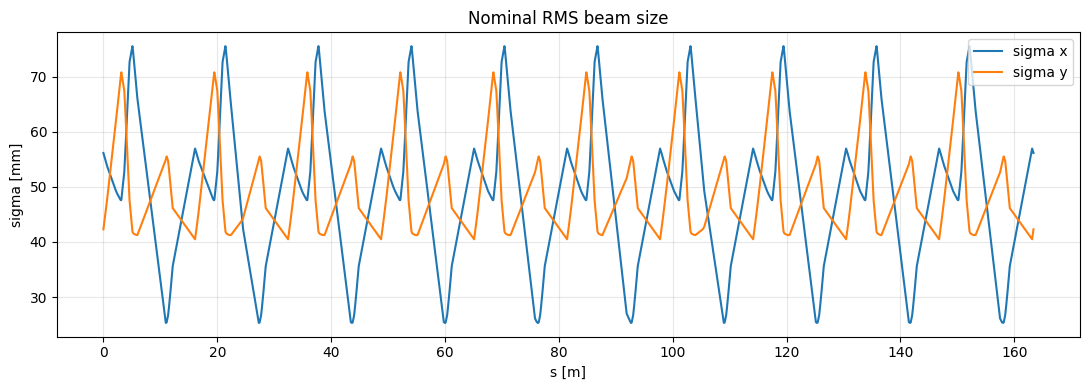

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_sigma(nominal, ax=ax, title="Nominal RMS beam size")
plt.tight_layout()

## Large harmonic effect on the envelope

The large harmonic settings modify the MAD-X optics. These comparison plots show how that propagates into the envelope.

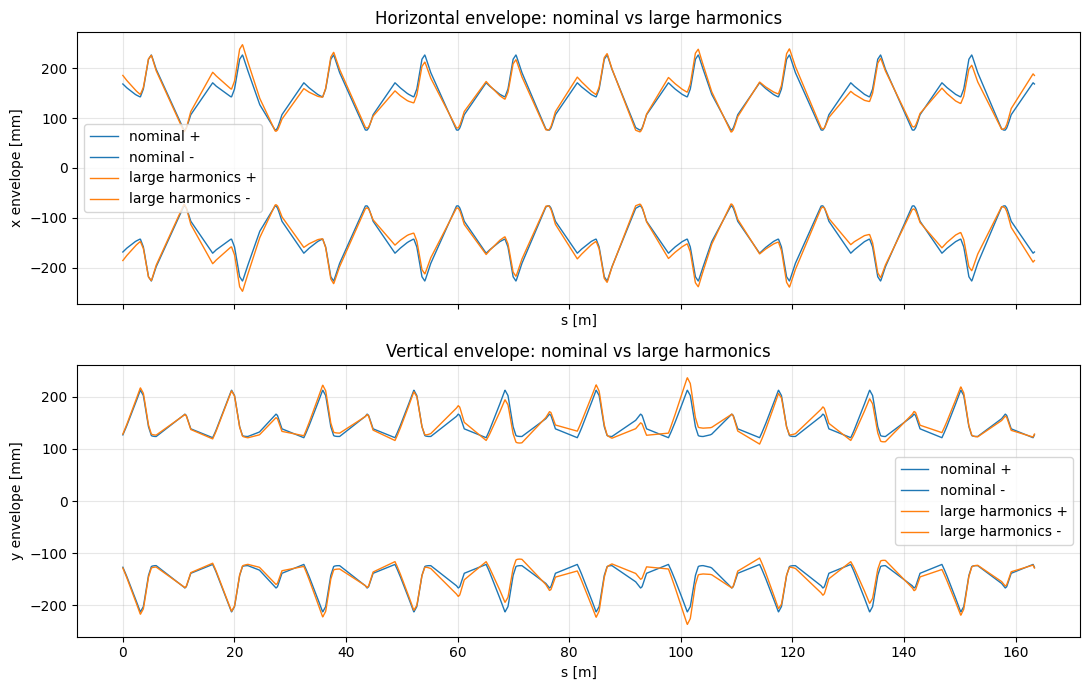

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_envelope_comparison([nominal, harmonic], plane="x", ax=axes[0], title="Horizontal envelope: nominal vs large harmonics")
plot_envelope_comparison([nominal, harmonic], plane="y", ax=axes[1], title="Vertical envelope: nominal vs large harmonics")
plt.tight_layout()

In [8]:
delta_summary = comparison.pivot(index="plane", columns="label", values="max_sigma_mm")
delta_summary["large_minus_nominal_mm"] = delta_summary["large harmonics"] - delta_summary["nominal"]
delta_summary

label,large harmonics,nominal,large_minus_nominal_mm
plane,,,
x,82.478700,75.585265,6.893435
y,78.810488,70.830435,7.980053



## Closed-orbit distortion plus envelope

This section applies a real MAD-X `SETERR` table through the existing orbit branch workflow. The same quadrupole offset is evaluated with nominal optics and with the deliberately large harmonic settings, so the GUI-style plots show orbit displacement and optics/envelope change together.


In [20]:

distortion_table = pd.DataFrame(
    [
        {
            "name": "sp0_qd:1",
            "dx": 1.0e-2,
            "dy": 1.0e-2,
            "ds": 0.0,
            "dphi": 0.0,
            "dtheta": 0.0,
            "dpsi": 0.0,
        }
    ]
)
distortion_path = write_error_table(
    distortion_table,
    OUTPUT_DIR / "closed_orbit_distortion_qd.tfs",
    table_name="CLOSED_ORBIT_DISTORTION_QD",
)

distorted_branch = OrbitBranch(
    OrbitBranchConfig(
        name="distorted_nominal",
        lattice_folder=LATTICE_FOLDER,
        machine_state=nominal_state,
        error_table_paths=[distortion_path],
        output_dir=OUTPUT_DIR / "distorted_nominal_branch",
        metadata={"case": "closed_orbit_distortion"},
    )
).run()

distorted_harmonic_branch = OrbitBranch(
    OrbitBranchConfig(
        name="distorted_large_harmonics",
        lattice_folder=LATTICE_FOLDER,
        machine_state=large_harmonic_state,
        error_table_paths=[distortion_path],
        output_dir=OUTPUT_DIR / "distorted_large_harmonic_branch",
        metadata={"case": "closed_orbit_distortion_large_harmonics"},
    )
).run()

distorted = evaluate_envelope_from_twiss(
    distorted_branch.twiss_df,
    inputs=EnvelopeInputs(label="distorted orbit"),
    beam_state=beam_state,
    source="orbit_branch_distortion",
    metadata=distorted_branch.metadata,
)

distorted_harmonic = evaluate_envelope_from_twiss(
    distorted_harmonic_branch.twiss_df,
    inputs=EnvelopeInputs(label="distorted + harmonics"),
    beam_state=beam_state,
    source="orbit_branch_distortion_large_harmonics",
    metadata=distorted_harmonic_branch.metadata,
)

nominal_to_distorted = compare_orbit_results(nominal.envelope_df, distorted_branch.orbit_df)
nominal_to_distorted_harmonic = compare_orbit_results(nominal.envelope_df, distorted_harmonic_branch.orbit_df)

distortion_summary = pd.DataFrame(
    [
        {"case": "distorted orbit", **summarise_orbit_difference(nominal_to_distorted)},
        {"case": "distorted + harmonics", **summarise_orbit_difference(nominal_to_distorted_harmonic)},
    ]
)
distortion_summary[["case", "max_abs_delta_x_mm", "max_abs_delta_y_mm", "rms_delta_x_mm", "rms_delta_y_mm"]]


,case,max_abs_delta_x_mm,max_abs_delta_y_mm,rms_delta_x_mm,rms_delta_y_mm
0,distorted orbit,23.031891,53.650343,10.801166,28.302066
1,distorted + harmonics,24.359915,56.892991,11.508853,29.793185



## Orbit displacement from the distortion

The closed orbit is plotted directly from the MAD-X TWISS output. This is the orbit centre that the envelope bands are wrapped around in the next plots.


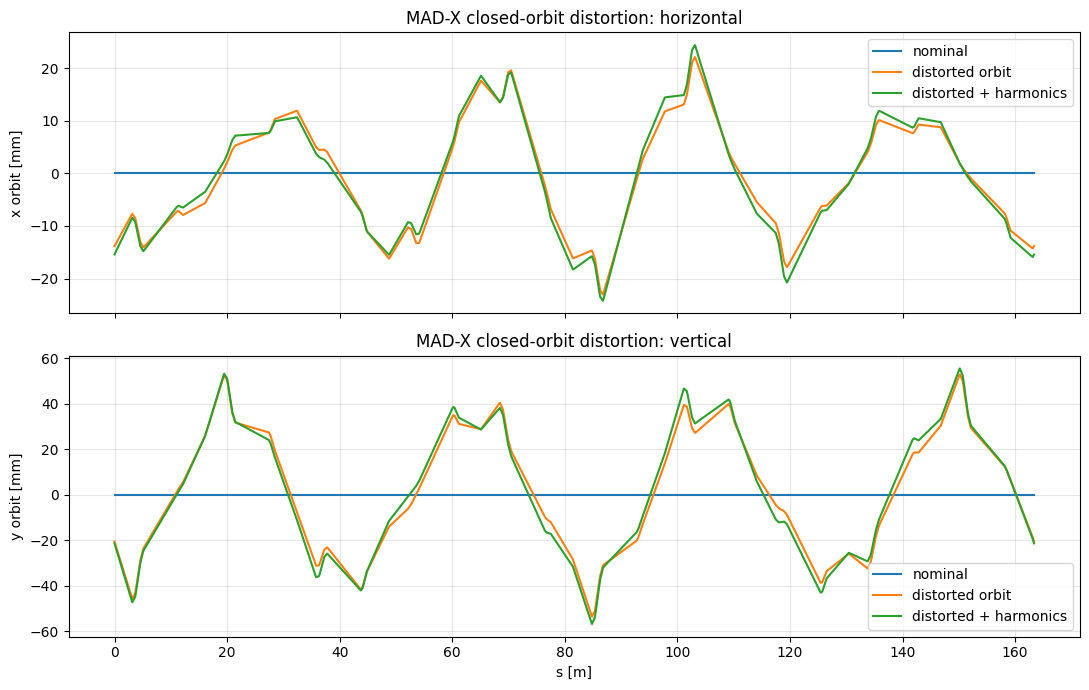

In [21]:

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for result, label in [
    (nominal, "nominal"),
    (distorted, "distorted orbit"),
    (distorted_harmonic, "distorted + harmonics"),
]:
    axes[0].plot(result.envelope_df["s"], result.envelope_df["orbit_x_mm"], label=label)
    axes[1].plot(result.envelope_df["s"], result.envelope_df["orbit_y_mm"], label=label)
axes[0].set_ylabel("x orbit [mm]")
axes[1].set_ylabel("y orbit [mm]")
axes[1].set_xlabel("s [m]")
axes[0].set_title("MAD-X closed-orbit distortion: horizontal")
axes[1].set_title("MAD-X closed-orbit distortion: vertical")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
plt.tight_layout()



## Envelope with harmonics and closed-orbit distortion

These plots combine the nominal envelope, harmonic optics change, closed-orbit distortion, and closed-orbit distortion with harmonic optics. The plus/minus bounds for each case deliberately use identical line style, width and colour.


,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,large harmonics,x,3.0,0.002,geometric,0.0003,0.0003,82.478700,sp1_qf:1,21.434382,247.436101,sp1_qf:1,21.434382,-247.436101,sp1_qf:1,21.434382
1,large harmonics,y,3.0,0.002,geometric,0.0003,0.0003,78.810488,sp6_qdfr4:1,101.168092,236.431464,sp6_qdfr4:1,101.168092,-236.431464,sp6_qdfr4:1,101.168092
2,distorted + harmonics,x,3.0,0.002,geometric,0.0003,0.0003,82.916802,sp1_qf:1,21.434382,263.148065,sp6_qf:1,103.115792,-260.766147,sp7_qf:1,119.452074
3,distorted + harmonics,y,3.0,0.002,geometric,0.0003,0.0003,79.199560,sp6_qdfr4:1,101.168092,284.215560,sp6_qdfr4:1,101.168092,-280.477207,sp5_qdfr4:1,84.831810


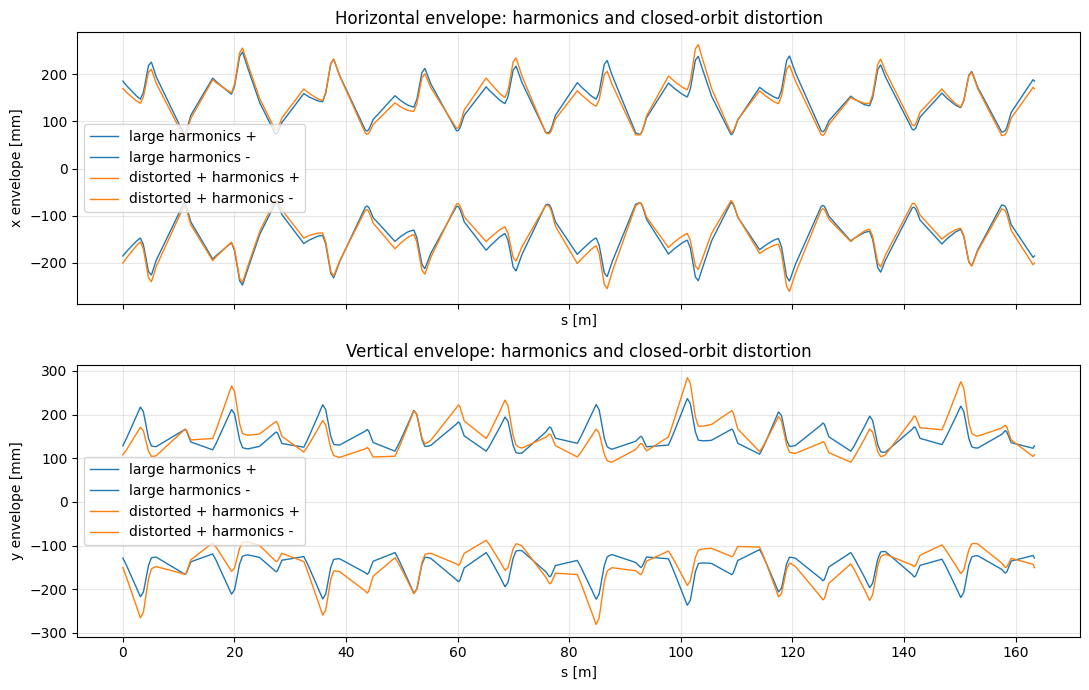

In [25]:

#all_envelope_cases = [nominal, harmonic, distorted, distorted_harmonic]

all_envelope_cases = [harmonic, distorted_harmonic]
all_envelope_comparison = compare_envelopes(all_envelope_cases)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_envelope_comparison(all_envelope_cases, plane="x", ax=axes[0], title="Horizontal envelope: harmonics and closed-orbit distortion")
plot_envelope_comparison(all_envelope_cases, plane="y", ax=axes[1], title="Vertical envelope: harmonics and closed-orbit distortion")
plt.tight_layout()

all_envelope_comparison


## Change sigma scale and emittance convention

The GUI should allow arbitrary positive sigma scale values and both geometric and normalised RMS emittance modes. Normalised mode requires the beam state so the layer can convert using beta-gamma.

In [23]:
five_sigma = evaluate_envelope_from_twiss(
    nominal.envelope_df,
    inputs=EnvelopeInputs(label="nominal 5 sigma", sigma_scale=5.0),
    beam_state=beam_state,
    source="existing_twiss_dataframe",
)

normalised = evaluate_envelope_from_twiss(
    nominal.envelope_df,
    inputs=EnvelopeInputs(label="normalised input", emittance_mode="normalised"),
    beam_state=beam_state,
    source="existing_twiss_dataframe",
)

pd.concat(
    [
        five_sigma.summary_df.assign(case="5 sigma geometric"),
        normalised.summary_df.assign(case="3 sigma normalised"),
    ],
    ignore_index=True,
)

,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m,case
0,nominal 5 sigma,x,5.0,0.002,geometric,0.000300,0.000300,75.585265,sp8_qf:1,135.788356,377.926325,sp8_qf:1,135.788356,-377.926325,sp8_qf:1,135.788356,5 sigma geometric
1,nominal 5 sigma,y,5.0,0.002,geometric,0.000300,0.000300,70.830435,sp8_qdfr4:1,133.840656,354.152175,sp8_qdfr4:1,133.840656,-354.152175,sp8_qdfr4:1,133.840656,5 sigma geometric
2,normalised input,x,3.0,0.002,normalised,0.000532,0.000532,99.961004,sp8_qf:1,135.788356,299.883013,sp8_qf:1,135.788356,-299.883013,sp8_qf:1,135.788356,3 sigma normalised
3,normalised input,y,3.0,0.002,normalised,0.000532,0.000532,94.298628,sp8_qdfr4:1,133.840656,282.895884,sp8_qdfr4:1,133.840656,-282.895884,sp8_qdfr4:1,133.840656,3 sigma normalised


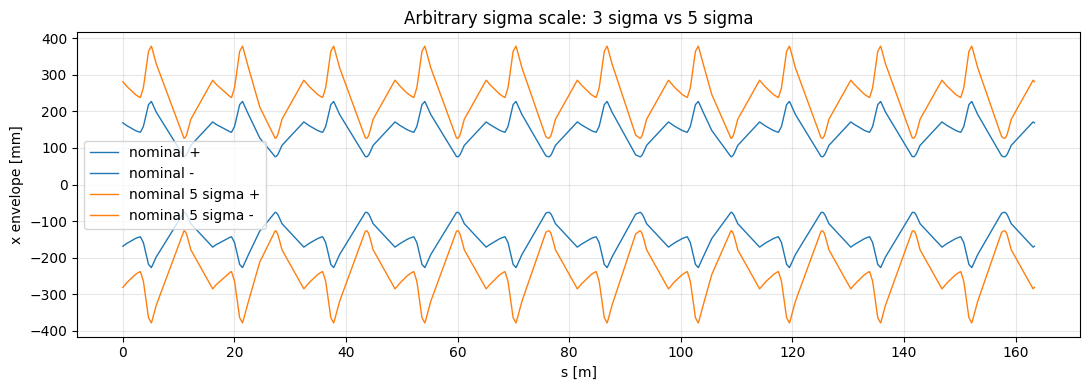

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_envelope_comparison([nominal, five_sigma], plane="x", ax=ax, title="Arbitrary sigma scale: 3 sigma vs 5 sigma")
plt.tight_layout()

## Assertions and failure modes

In [14]:
for result in [nominal, harmonic, distorted, distorted_harmonic, five_sigma, normalised]:
    df = result.envelope_df
    required = [
        "sigma_x_m", "sigma_y_m",
        "envelope_x_plus_mm", "envelope_x_minus_mm",
        "envelope_y_plus_mm", "envelope_y_minus_mm",
    ]
    assert all(col in df.columns for col in required)
    assert np.isfinite(df[required].to_numpy()).all()
    assert (df["sigma_x_m"] >= 0.0).all()
    assert (df["sigma_y_m"] >= 0.0).all()
    assert (df["envelope_x_plus_m"] >= df["x"]).all()
    assert (df["envelope_x_minus_m"] <= df["x"]).all()
    assert (df["envelope_y_plus_m"] >= df["y"]).all()
    assert (df["envelope_y_minus_m"] <= df["y"]).all()

assert np.isclose(pi_mm_mrad_to_m_rad(300.0), 300e-6)

geom_x, geom_y = geometric_emittances_m_rad(EnvelopeInputs())
norm_x, norm_y = geometric_emittances_m_rad(
    EnvelopeInputs(emittance_mode="normalised"),
    beam_state=beam_state,
)
assert np.isclose(norm_x, geom_x / (beam_state.beta * beam_state.gamma))
assert np.isclose(norm_y, geom_y / (beam_state.beta * beam_state.gamma))

try:
    evaluate_envelope_from_twiss(
        nominal.envelope_df.drop(columns=["betx"]),
        inputs=EnvelopeInputs(),
        beam_state=beam_state,
    )
    raise AssertionError("Missing TWISS column did not fail")
except ValueError as exc:
    assert "missing required envelope columns" in str(exc).lower()

try:
    evaluate_envelope_from_twiss(
        nominal.envelope_df,
        inputs=EnvelopeInputs(emit_x_pi_mm_mrad=-1.0),
        beam_state=beam_state,
    )
    raise AssertionError("Negative emittance did not fail")
except ValueError as exc:
    assert "emit_x_pi_mm_mrad" in str(exc)

try:
    evaluate_envelope_from_twiss(
        nominal.envelope_df,
        inputs=EnvelopeInputs(emittance_mode="normalised"),
        beam_state=None,
    )
    raise AssertionError("Normalised emittance without beam_state did not fail")
except ValueError as exc:
    assert "requires a beam_state" in str(exc)

assert abs(inputs_nominal.dp_over_p - 0.002) < 1e-15
assert abs(inputs_nominal.sigma_scale - 3.0) < 1e-15
assert abs(inputs_nominal.emit_x_pi_mm_mrad - 300.0) < 1e-15
assert not comparison.empty
assert "large harmonics" in set(comparison["label"])
assert distorted_branch.metadata["errors_applied"] is True
assert distorted_harmonic_branch.metadata["errors_applied"] is True
assert distortion_summary["max_abs_delta_x_mm"].max() > 1.0
assert distortion_summary["max_abs_delta_y_mm"].max() > 0.1
assert "distorted + harmonics" in set(all_envelope_comparison["label"])

style_fig, style_ax = plt.subplots()
plot_envelope(nominal, plane="x", ax=style_ax)
plus_line, minus_line = style_ax.lines[1], style_ax.lines[2]
assert plus_line.get_color() == minus_line.get_color()
assert plus_line.get_linewidth() == minus_line.get_linewidth()
assert plus_line.get_linestyle() == minus_line.get_linestyle()
plt.close(style_fig)

comparison_style_fig, comparison_style_ax = plt.subplots()
plot_envelope_comparison(all_envelope_cases, plane="x", ax=comparison_style_ax)
for plus_line, minus_line in zip(comparison_style_ax.lines[0::2], comparison_style_ax.lines[1::2]):
    assert plus_line.get_color() == minus_line.get_color()
    assert plus_line.get_linewidth() == minus_line.get_linewidth()
    assert plus_line.get_linestyle() == minus_line.get_linestyle()
plt.close(comparison_style_fig)

print("MAD-X envelope notebook checks passed")

MAD-X envelope notebook checks passed
